## Introduction:

This project analyzes car accidents in the United States from 2017 to 2022 using a dataset obtained from Kaggle. The dataset contains accident records across 49 U.S. states and provides valuable information about accident frequency, location, weather conditions, time, and severity. Through data analysis and visualization, this project aims to identify trends and insights related to road accidents in the United States.

This analysis was completed as the final project requirement for the General Assembly Data Analysis Bootcamp.

## Problem Statement:

Road accidents in the United States have become an increasing safety concern over recent years. Between 2017 and 2022, the number of reported car accidents increased by approximately 143.8%, indicating significant growth in traffic incidents across the country.

## Objectives:

The main objective of this project is to improve driver safety by analyzing car accident patterns and identifying factors that contribute to road accidents in the United States. By understanding accident trends, drivers and The National Highway and Traffic Safety Administration (NHTSA) can take preventive measures to reduce traffic incidents and improve road awareness.

## Target Audience:

The primary target audience of this project is drivers and road users who can benefit from understanding accident patterns and road safety risks. The insights from this analysis can help increase driver awareness and encourage safer driving practices to reduce the likelihood of accidents.
This project also useful for transportation authorities, traffic safety organizations, insurance companies, and healthcare institutions. Reducing accidents can lead to fewer injuries, less traffic congestion, lower medical and hospital treatment costs, and reduced vehicle insurance expenses, benefiting both individuals and society as a whole.

## Dataset(s):

https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents/data

## Data Handling:

In [38]:
import pandas as pd

In [39]:
df = pd.read_csv(r"C:\Users\YYAYALN\Desktop\Final project\US_Accidents_March23.csv/US_Accidents.csv",parse_dates=['Start_Time','End_Time','Weather_Timestamp'])   # changed the data type to dates     #nrows=100

In [40]:
filtered = (df['Start_Time'] >= "2017-01-01 00:00:00") & (df['Start_Time'] <= "2022-12-31 23:59:59")  # Remove first and last years "2016","2023" for missing months

In [41]:
df = df[filtered]

In [42]:
df.head(5)

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
9206,A-9207,Source2,3,2017-01-01 00:17:36,2017-01-01 00:47:12,37.925392,-122.320595,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Night,Night
9207,A-9208,Source2,3,2017-01-01 00:26:08,2017-01-01 01:16:06,37.878185,-122.307175,NaN,NaN,0.01,...,False,False,True,False,False,False,Night,Night,Night,Night
9208,A-9209,Source2,2,2017-01-01 00:53:41,2017-01-01 01:22:35,38.014820,-121.640579,NaN,NaN,0.00,...,False,False,False,False,False,False,Night,Night,Night,Night
9209,A-9210,Source2,3,2017-01-01 01:18:51,2017-01-01 01:48:01,37.912056,-122.323982,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
9210,A-9211,Source2,3,2017-01-01 01:20:12,2017-01-01 01:49:47,37.925392,-122.320595,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Night,Night


In [43]:
df.columns

Index(['ID', 'Source', 'Severity', 'Start_Time', 'End_Time', 'Start_Lat',
       'Start_Lng', 'End_Lat', 'End_Lng', 'Distance(mi)', 'Description',
       'Street', 'City', 'County', 'State', 'Zipcode', 'Country', 'Timezone',
       'Airport_Code', 'Weather_Timestamp', 'Temperature(F)', 'Wind_Chill(F)',
       'Humidity(%)', 'Pressure(in)', 'Visibility(mi)', 'Wind_Direction',
       'Wind_Speed(mph)', 'Precipitation(in)', 'Weather_Condition', 'Amenity',
       'Bump', 'Crossing', 'Give_Way', 'Junction', 'No_Exit', 'Railway',
       'Roundabout', 'Station', 'Stop', 'Traffic_Calming', 'Traffic_Signal',
       'Turning_Loop', 'Sunrise_Sunset', 'Civil_Twilight', 'Nautical_Twilight',
       'Astronomical_Twilight'],
      dtype='str')

In [44]:
df.info()

<class 'pandas.DataFrame'>
Index: 7070940 entries, 9206 to 7728393
Data columns (total 46 columns):
 #   Column                 Dtype         
---  ------                 -----         
 0   ID                     str           
 1   Source                 str           
 2   Severity               int64         
 3   Start_Time             str           
 4   End_Time               str           
 5   Start_Lat              float64       
 6   Start_Lng              float64       
 7   End_Lat                float64       
 8   End_Lng                float64       
 9   Distance(mi)           float64       
 10  Description            str           
 11  Street                 str           
 12  City                   str           
 13  County                 str           
 14  State                  str           
 15  Zipcode                str           
 16  Country                str           
 17  Timezone               str           
 18  Airport_Code           str         

In [45]:
df['Start_Time'] = df['Start_Time'] = pd.to_datetime(df['Start_Time'], format='mixed')    # Unite the date Format For Between All dates

In [46]:
df['End_Time'] = df['End_Time'] = pd.to_datetime(df['End_Time'], format='mixed')          # Unite the date Format For Between All dates

In [47]:
df.dtypes

ID                                  str
Source                              str
Severity                          int64
Start_Time               datetime64[ns]
End_Time                 datetime64[ns]
Start_Lat                       float64
Start_Lng                       float64
End_Lat                         float64
End_Lng                         float64
Distance(mi)                    float64
Description                         str
Street                              str
City                                str
County                              str
State                               str
Zipcode                             str
Country                             str
Timezone                            str
Airport_Code                        str
Weather_Timestamp        datetime64[us]
Temperature(F)                  float64
Wind_Chill(F)                   float64
Humidity(%)                     float64
Pressure(in)                    float64
Visibility(mi)                  float64


In [48]:
df = df.drop(columns= "ID")             # the ID randomly generated so the data could have duplicates

In [49]:
df.duplicated().sum()                   # Shows the number of duplicated rows

np.int64(115409)

In [50]:
df.drop_duplicates(inplace = True)      # remove duplicates

In [51]:
df.sort_values(by='Start_Time', ascending=True, inplace=True)       #sorted by time ascending

In [52]:
df.set_index("Start_Time",drop=False,inplace=True)    # add new index 

In [53]:
df.isna().sum()

Source                         0
Severity                       0
Start_Time                     0
End_Time                       0
Start_Lat                      0
Start_Lng                      0
End_Lat                  3119349
End_Lng                  3119349
Distance(mi)                   0
Description                    5
Street                      9874
City                         221
County                         0
State                          0
Zipcode                     1710
Country                        0
Timezone                    7359
Airport_Code               21173
Weather_Timestamp         108698
Temperature(F)            147531
Wind_Chill(F)            1612996
Humidity(%)               156417
Pressure(in)              126738
Visibility(mi)            157647
Wind_Direction            159888
Wind_Speed(mph)           481129
Precipitation(in)        1808926
Weather_Condition         154523
Amenity                        0
Bump                           0
Crossing  

In [54]:
df = df.drop(columns=['Country','End_Lat','End_Lng','Description','Zipcode','Weather_Timestamp','Airport_Code'])     # Drop Useless culomns

In [55]:
df = df.dropna(subset=['City'])#,'Sunrise_Sunset','Civil_Twilight','Nautical_Twilight','Astronomical_Twilight',"Street","Timezone","Temperature(F)","Wind_Chill(F)","Humidity(%)","Pressure(in)","Visibility(mi)","Wind_Direction","Wind_Speed(mph)","Precipitation(in)","Weather_Condition"]) 
# Drop nulls

In [56]:
df["Traffic Duration"] = df["End_Time"] - df["Start_Time"]    # Add culomn for traffic duration

In [57]:
df.isna().sum()

Source                         0
Severity                       0
Start_Time                     0
End_Time                       0
Start_Lat                      0
Start_Lng                      0
Distance(mi)                   0
Street                      9874
City                           0
County                         0
State                          0
Timezone                    7357
Temperature(F)            147525
Wind_Chill(F)            1612959
Humidity(%)               156411
Pressure(in)              126731
Visibility(mi)            157639
Wind_Direction            159884
Wind_Speed(mph)           481118
Precipitation(in)        1808891
Weather_Condition         154514
Amenity                        0
Bump                           0
Crossing                       0
Give_Way                       0
Junction                       0
No_Exit                        0
Railway                        0
Roundabout                     0
Station                        0
Stop      

In [58]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 6955310 entries, 2017-01-01 00:00:26 to 2022-12-31 23:59:03
Data columns (total 39 columns):
 #   Column                 Dtype          
---  ------                 -----          
 0   Source                 str            
 1   Severity               int64          
 2   Start_Time             datetime64[ns] 
 3   End_Time               datetime64[ns] 
 4   Start_Lat              float64        
 5   Start_Lng              float64        
 6   Distance(mi)           float64        
 7   Street                 str            
 8   City                   str            
 9   County                 str            
 10  State                  str            
 11  Timezone               str            
 12  Temperature(F)         float64        
 13  Wind_Chill(F)          float64        
 14  Humidity(%)            float64        
 15  Pressure(in)           float64        
 16  Visibility(mi)         float64        
 17  Wind_Direction         s

## Analysis and Findings

### Overall View

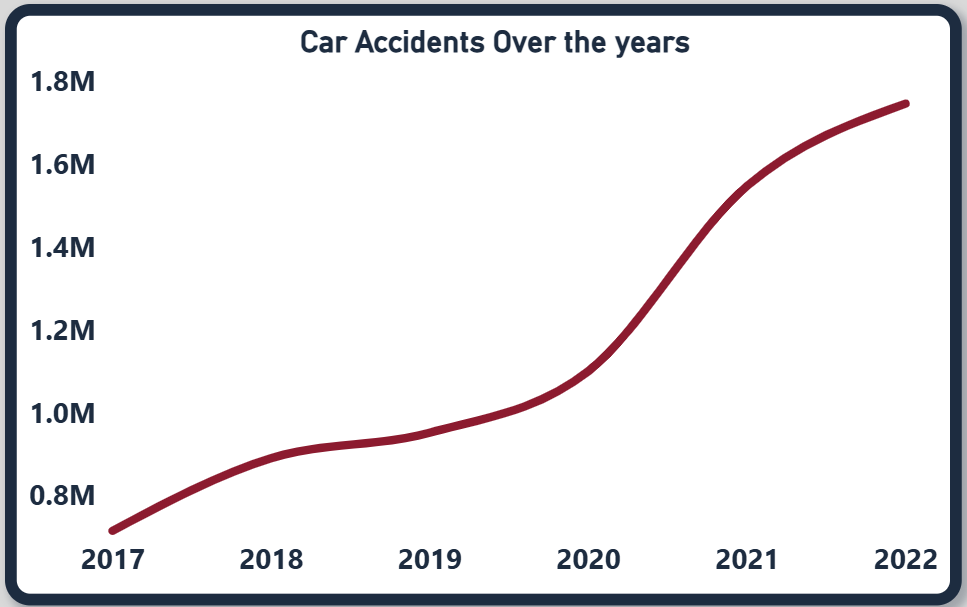

- Over the period 2017–2022, car accidents more than doubled, with an overall growth rate of 143.8%.
- A noticeable decline in accidents occurred between 2019 and 2020, most likely due to the impact of the COVID-19 pandemic and reduced travel activity.

### Number of Cars Accidents

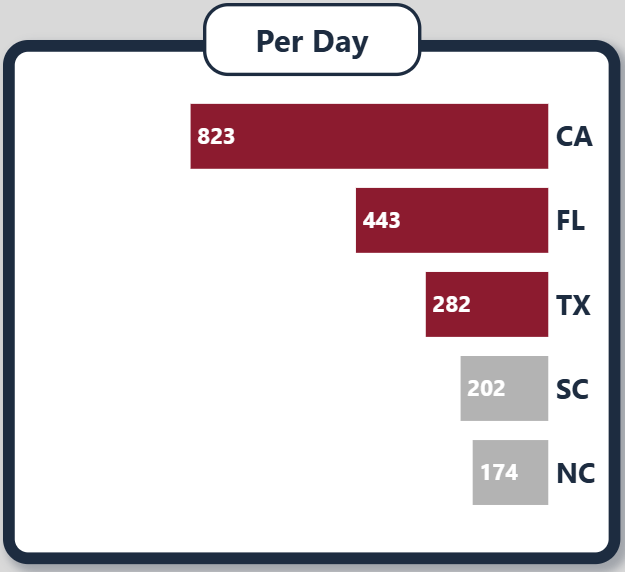 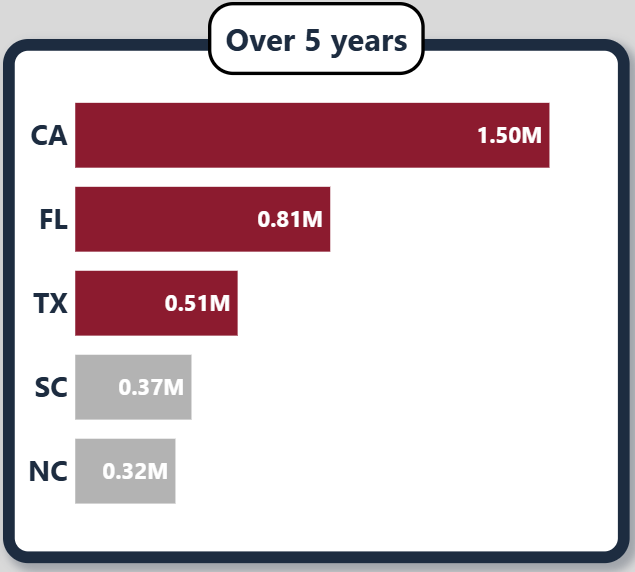

The states with the highest number of car accidents in the United States are California, Florida, and Texas. California ranks first, with more than 1.5 million accidents recorded over 5 years  averaging approximately (823 accidents per day).

### Accidents Peak Time

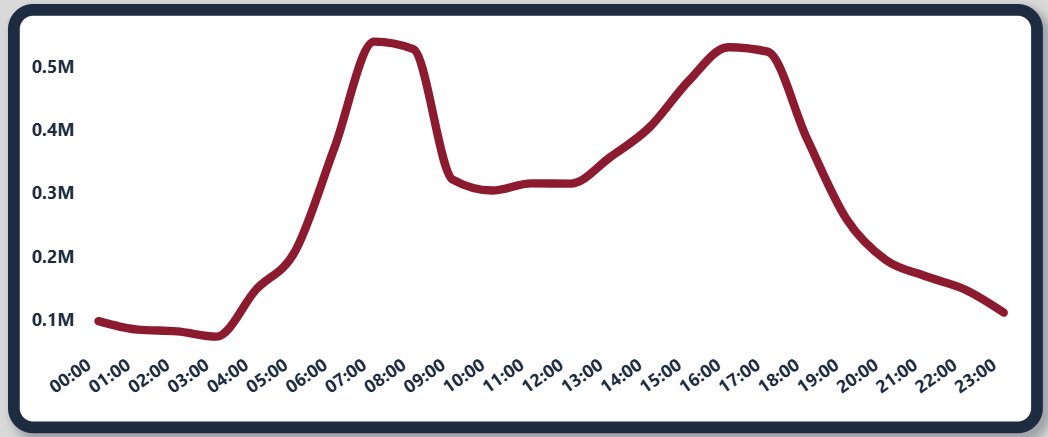

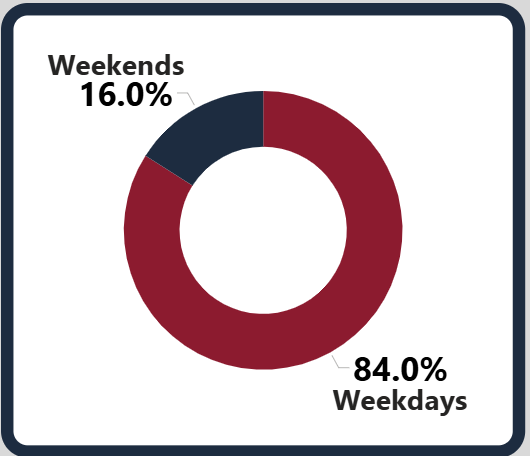 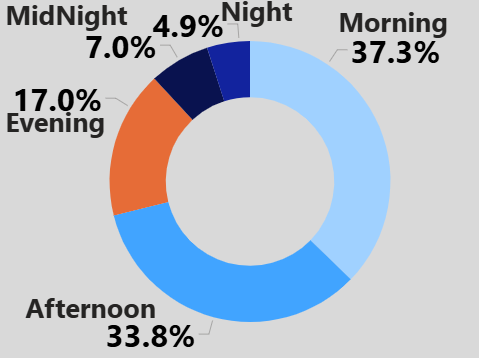

Most accidents occur on weekdays, usually during work commuting hours around 8:00 AM and 5:00 PM. On weekends, accident rates tend to peak around 2:00 PM.

### Seasonal Car Accidents

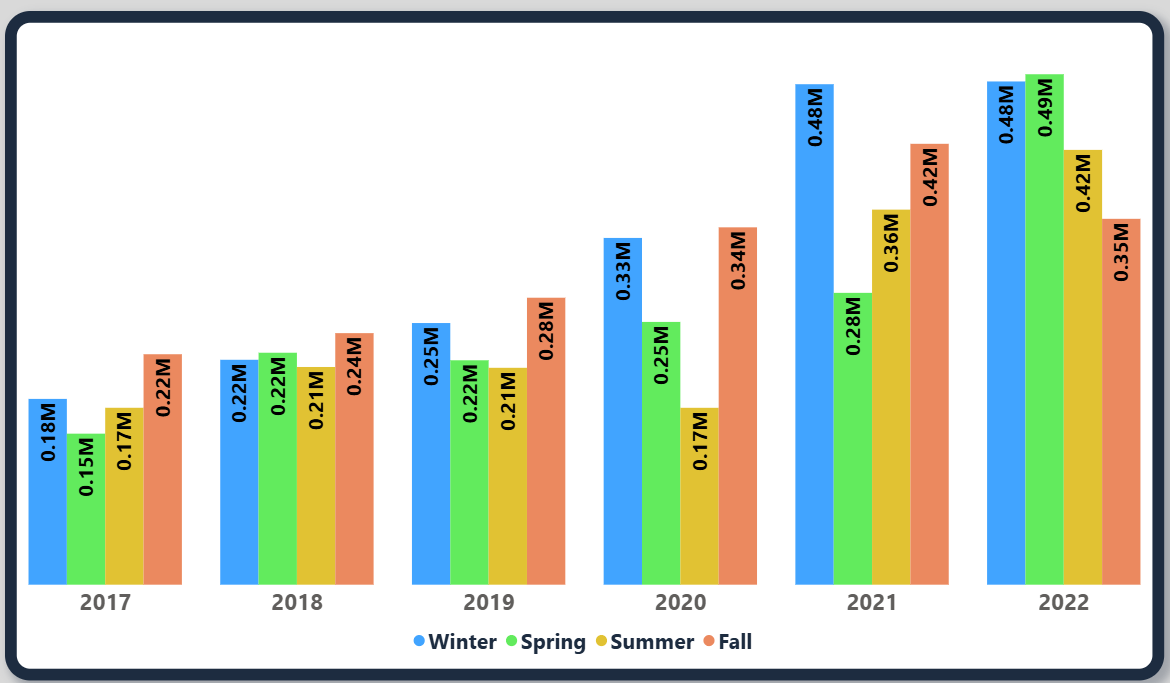

Number of accidents have been Increasing yearly, with the Fall and Winter Seasons contributing to more accidents.

### Weather Impact in Accident Severity

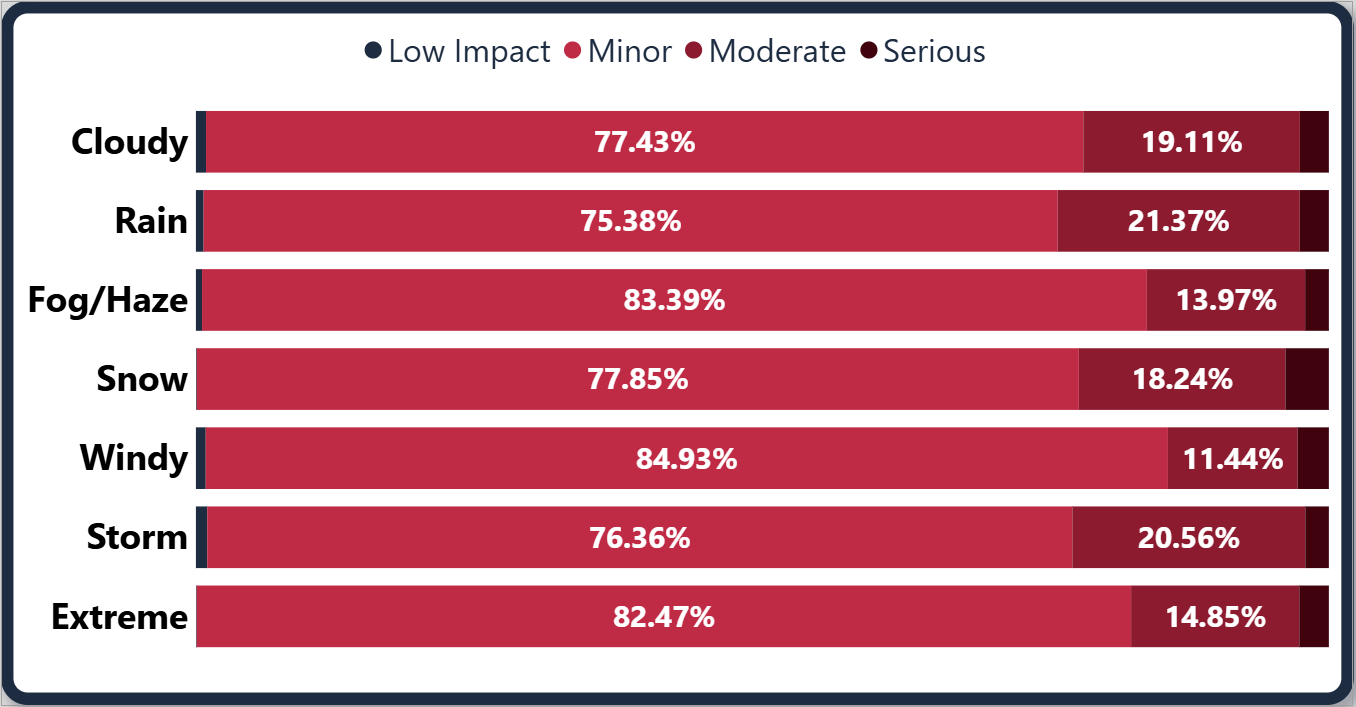

The Weather Condition has low impact on the Severity of the Accident.

### State View

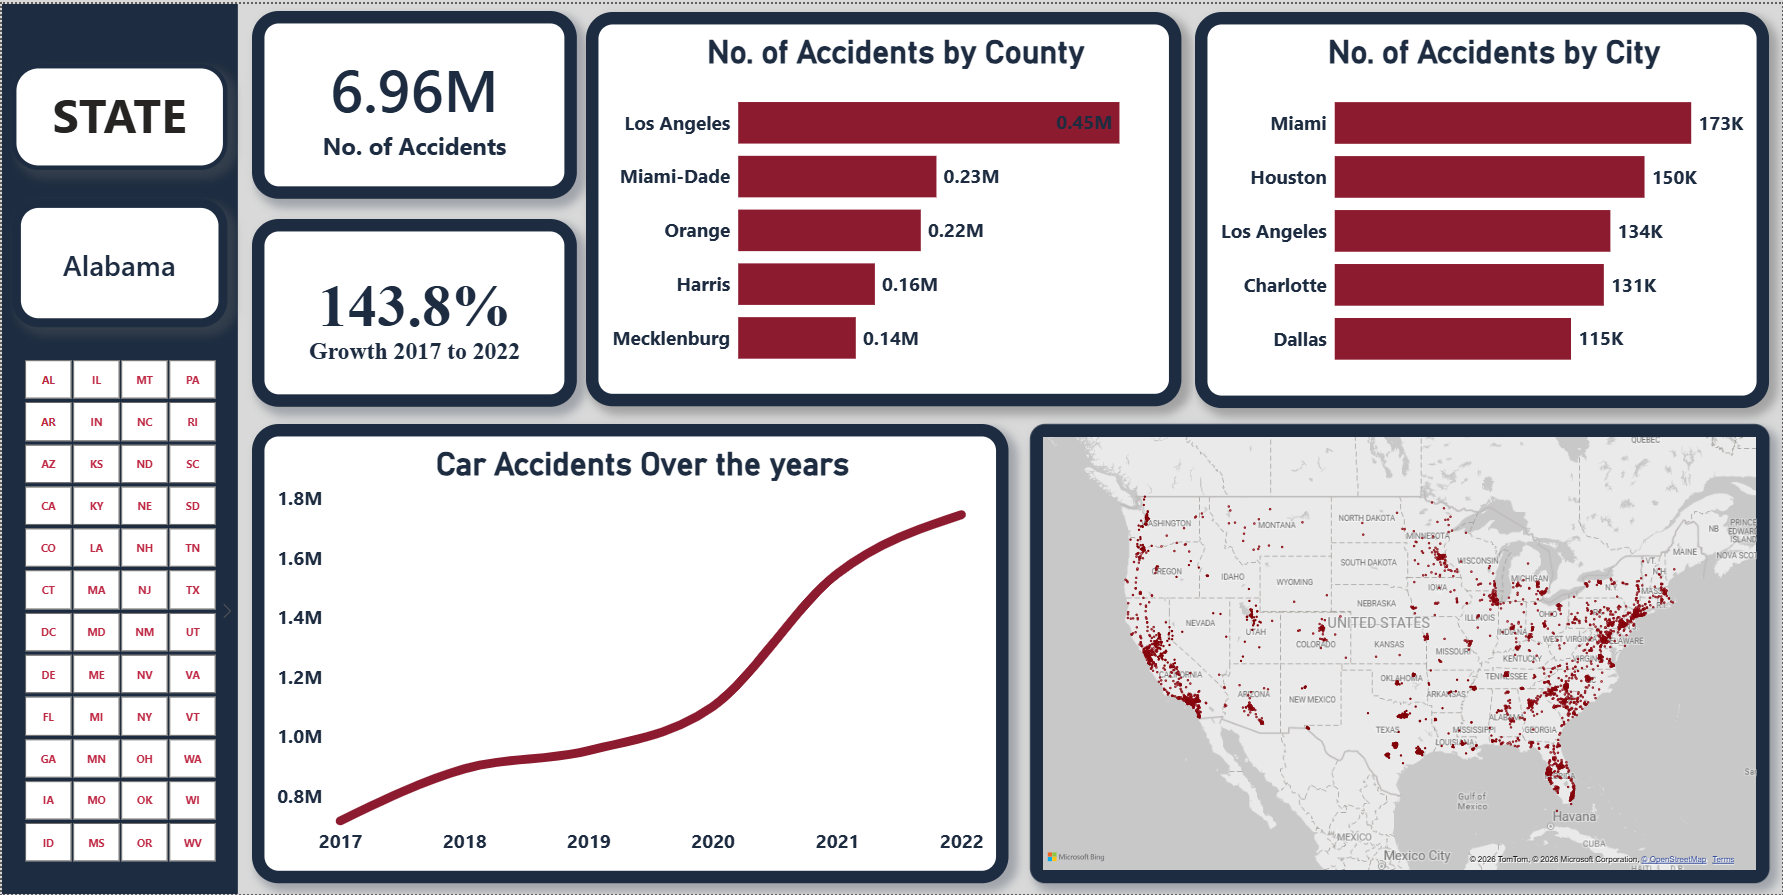

It shows the previous charts, but with more focus on counties and cities using interactive filters.

## Recommendations

- Focus on high accident roads during peak work hours, especially in winter.
- Enhance traffic flow during rush hours to reduce congestion and collisions.
- Improve road organization and traffic management in high risk areas.
- Increase safety measures on accident prone roads in winter conditions.

## Limitations and Assumptions


The dataset contained many missing (null) values and lacked important information, such as the drivers’ ages and the severity of injuries resulting from the accidents, which limited the depth and accuracy of the analysis.

## References

https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents/data                         # The data used for the analasis

https://www.hastingsandhastings.com/who-is-in-charge-of-vehicle-and-road-safety/ # Road Safety 

https://learn.microsoft.com/en-us/bingmaps/rest-services/traffic/get-traffic-incidents#supported-http-methods

## My Extra(s)

In [61]:
df.to_csv("US_Accidents_2017_2022.csv",index=False)

In [72]:
df["Weather_Condition"].unique

<bound method Series.unique of Start_Time
2017-01-01 00:00:26       Light Rain
2017-01-01 00:00:26       Light Rain
2017-01-01 00:03:31            Clear
2017-01-01 00:06:45       Light Rain
2017-01-01 00:09:26            Clear
                           ...      
2022-12-31 23:59:00    Mostly Cloudy
2022-12-31 23:59:00       Light Rain
2022-12-31 23:59:00       Heavy Rain
2022-12-31 23:59:00       Light Rain
2022-12-31 23:59:03           Cloudy
Name: Weather_Condition, Length: 6955310, dtype: str>

In [76]:
dfw = df["Weather_Condition"].unique()

In [74]:
dfw.to_csv("weather_condition",index=False)

AttributeError: 'function' object has no attribute 'to_csv'

In [81]:
pd.DataFrame(dfw).to_csv("weather_condition.csv",index=False)

In [78]:
 df["Weather_Condition"].unique()

<StringArray>
[                 'Light Rain',                       'Clear',
               'Mostly Cloudy',                           nan,
                    'Overcast',                        'Haze',
               'Partly Cloudy',            'Scattered Clouds',
               'Heavy Drizzle',                  'Light Snow',
 ...
                   'Duststorm',   'Heavy Rain Shower / Windy',
                'Sand / Windy',    'Snow and Thunder / Windy',
         'Blowing Snow Nearby', 'Heavy Freezing Rain / Windy',
     'Heavy Sleet and Thunder',           'Sleet and Thunder',
         'Shallow Fog / Windy',       'Drifting Snow / Windy']
Length: 143, dtype: str